In [1]:
import os
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc
import torch
from scipy.stats import pearsonr

sys.path.append('../../..')
import sherlock as slk

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
DEVICE          = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
N_RUNS          = 5
NUM_EPOCHS      = 200
VALIDATE_EVERY = 50
BATCH_SIZE      = 4096
LATENT_DIM      = 16
PATIENCE        = 20
HOLDOUT_FRAC   = 0.20
HOLDOUT_SEED   = 42
RESULTS_DIR    = 'results/benchmarking_combinatorial'

# --- OPTUNA TUNED BEST HYPERPARAMETERS ---

# sherlock (vae) tuned spaces
_SLK_BEST = {
    'combinatorial': True,
    'l0_lambda': 5.759491158946374,
    'ce_lambda': 14.880548457832543,
    'tau_end': 0.20343885211152185,
    'n_epochs_kl_warmup': 141,
    'n_epochs_l0_warmup': 179, # Calculated from kl_warmup (141) + offset (38)
}

# cvae tuned spaces
_CVAE_BEST = {
    'combinatorial': True,
    'beta': 0.864373149647393,
    'n_hidden': 75,
    'n_layers': 3,
    'dropout_rate': 0.18033450352296262,
    'lr': 0.0026070247583707684
}

# svae tuned spaces
_SVAE_BEST = {
    'combinatorial': True,
    'sparse_mask_penalty': 1.2621246026353048,
    'beta': 1.01982588017168,
    'n_hidden': 91,
    'n_layers': 3,
    'dropout_rate': 0.27679982217483157,
    'lr': 0.0025676424778194175
}

# contrastivevi tuned spaces
_CVI_BEST = {
    'combinatorial': True,
    'wasserstein_penalty': 8.529553883240832,
    'n_hidden': 91,
    'n_layers': 2,
    'dropout_rate': 0.27340534477981465,
    'lr': 0.005586629355057471
}

# scgen tuned spaces (does not accept 'combinatorial')
_SCGEN_BEST = {
    'kl_weight': 2.8897946998966042e-05,
    'n_hidden': 131,
    'n_layers': 3,
    'dropout_rate': 0.17802697113827265,
    'lr': 0.003274999191150255
}

# (model_key, display_name, extra_kwargs, num_epochs)
METHODS = [
    ('vae',           'sherlock',         {**_SLK_BEST},                       500),
    ('vae',           'sherlock_synergy', {**_SLK_BEST, 'synergy': True}, 500),
    ('cvae',          'cVAE',             {**_CVAE_BEST},                      200),
    ('svae',          'sVAE',             {**_SVAE_BEST},                      200),
    ('contrastivevi', 'contrastiveVI',    {**_CVI_BEST},                       200),
    ('scgen',         'scgen',            {**_SCGEN_BEST},                     200),
]

METRIC_COLS = [
    'ate_all_r',
    'ate_single_r',
    'ate_train_combo_r',
    'ate_held_r',
    'rho_z_pearson_r',
]

os.makedirs(f'{RESULTS_DIR}/models',  exist_ok=True)
os.makedirs(f'{RESULTS_DIR}/figures', exist_ok=True)
print(f'Device: {DEVICE}  Results: {RESULTS_DIR}')

Device: cuda  Results: results/benchmarking_combinatorial


## Data loading and gene filtering

In [4]:
data = sc.read_h5ad('../Norman_2019.h5ad')
data.X = data.layers['counts'].copy()
slk.pp.slk_prepare_data(
    data,
    pert_key='perturbation_name',
    ntc_label='control',
    treatment_key=None,
    inplace=True,
)

p_key = slk.configs.get_config('pert_key')
NTC   = slk.configs.get_config('ntc_label')

all_perts    = data.obs[p_key].unique()
single_perts = [p for p in all_perts if '+' not in str(p) and p != NTC]
combo_perts  = [p for p in all_perts if '+' in str(p)]

# Gene filtering: top 2000 HVG union with perturbation target genes
pert_genes = set(g.strip() for p in all_perts if p != NTC for g in str(p).split('+'))
sc.pp.highly_variable_genes(data, n_top_genes=2000, flavor='seurat_v3', subset=False)
keep_mask = data.var['highly_variable'] | data.var_names.isin(pert_genes)
data = data[:, keep_mask].copy()

print(f'Cells: {data.n_obs}   Genes: {data.n_vars}')
print(f'Single perts: {len(single_perts)}   Combo perts: {len(combo_perts)}   NTC cells: {(data.obs[p_key]==NTC).sum()}')

Cells: 111255   Genes: 2040
Single perts: 105   Combo perts: 131   NTC cells: 11835


## Ground-truth treatment effects

Computed on the **full** dataset (including held-out combos) so we have a ground-truth ATE reference for all perturbations.

In [5]:
slk.pp.treat_effect(
    data,
    label_col='pert',
    control_label='NTC',
    method='perturbseq',
    inplace=True,
    key='treat_effect',
)
treat_effect_adata = data.uns['treat_effect']
print(f'treat_effect: {treat_effect_adata.n_obs} perturbations × {treat_effect_adata.n_vars} genes')

100%|████████████████████████████████████████████████████████████████████████| 236/236 [00:05<00:00, 41.07it/s]

treat_effect: 236 perturbations × 2040 genes


## Hold-out split (20% of combo perturbations)

A fixed random 20% of combo perts are withheld from **all** models' training data.  
`ate_held_r` on these tests each model's out-of-distribution combinatorial prediction.

In [6]:
rng           = np.random.default_rng(HOLDOUT_SEED)
combo_arr     = np.array(sorted(combo_perts))
n_holdout     = max(1, int(np.round(len(combo_arr) * HOLDOUT_FRAC)))
holdout_combos = set(combo_arr[rng.choice(len(combo_arr), size=n_holdout, replace=False)])
train_combos   = set(combo_arr) - holdout_combos

train_data = data[~data.obs[p_key].isin(holdout_combos)].copy()

print(f'Total combo perts : {len(combo_perts)}')
print(f'Training combos   : {len(train_combos)}')
print(f'Hold-out combos   : {len(holdout_combos)}  ({len(holdout_combos)/len(combo_perts):.1%})')
print(f'Training cells    : {train_data.n_obs} / {data.n_obs}')

Total combo perts : 131
Training combos   : 105
Hold-out combos   : 26  (19.8%)
Training cells    : 103000 / 111255


## Evaluation helper

In [7]:
def _ate_r(pred_df, obs_df, idx):
    idx = [p for p in idx if p in pred_df.index and p in obs_df.index]
    if len(idx) < 2:
        return float('nan')
    x = pred_df.loc[idx].values.ravel()
    y = obs_df.loc[idx].values.ravel()
    v = np.isfinite(x) & np.isfinite(y)
    return float(pearsonr(x[v], y[v])[0]) if v.sum() > 2 else float('nan')


def evaluate_combinatorial(
    model, train_adata, full_adata, treat_effect_adata,
    single_perts, train_combos, holdout_combos, device
):
    """Compute ATE breakdown and rho-z consistency. No cluster ground-truth required."""
    # Inference on training data → rho_corr / z_corr
    slk.tl.eval(model, train_adata, obsm_key='z', uns_key='_bench_tmp', device=device)
    res = train_adata.uns['_bench_tmp']

    rho_z_r = float('nan')
    rho_mat = res.get('rho_corr')
    z_mat   = res.get('z_corr')
    if rho_mat is not None and z_mat is not None:
        rho = np.asarray(rho_mat, dtype=float)
        z   = np.asarray(z_mat,   dtype=float)
        if rho.shape == z.shape and rho.shape[0] >= 2:
            triu = np.triu_indices(rho.shape[0], k=1)
            rf, zf = rho[triu], z[triu]
            v = np.isfinite(rf) & np.isfinite(zf)
            if v.sum() > 2:
                rho_z_r = float(abs(pearsonr(rf[v], zf[v])[0]))

    # ATE: predict for all perts including held-out combos
    try:
        ate = model.predict_counterfactual_effects(
            full_adata, n_centroids=25, observed_effect=treat_effect_adata
        )
    except Exception as e:
        print(f'  Warning: ATE on full data failed ({e}), using train_adata')
        ate = model.predict_counterfactual_effects(
            train_adata, n_centroids=25, observed_effect=treat_effect_adata
        )

    pred = ate['predicted_df']
    obs  = ate['observed_df']

    return {
        'ate_all_r':         ate['corr'],
        'ate_single_r':      _ate_r(pred, obs, single_perts),
        'ate_train_combo_r': _ate_r(pred, obs, list(train_combos)),
        'ate_held_r':        _ate_r(pred, obs, list(holdout_combos)),
        'rho_z_pearson_r':   rho_z_r,
    }

## Benchmark loop

Each method is trained `N_RUNS` times on the training subset (all singles + NTC + 80% combos).  
The best-scoring run per method (by mean of `METRIC_COLS`) is saved to disk.

**Note:** `ate_held_r` will be NaN for non-combinatorial methods (e.g. scgen) that cannot predict unseen combo labels.

In [ ]:
records        = []
best_run_out   = {}
best_run_score = {}

for model_key, display_name, extra_kwargs, method_epochs in METHODS:
    print(f"\n{'='*60}\n{display_name}  ({N_RUNS} runs, {method_epochs} epochs)\n{'='*60}")
    best_run_score[display_name] = -np.inf

    for run in range(N_RUNS):
        print(f'  -- {display_name} run {run+1}/{N_RUNS} --')

        out = slk.tl.run(
            train_data,
            model=model_key,
            batch_size=BATCH_SIZE,
            num_epochs=method_epochs,
            device=DEVICE,
            latent_dim=LATENT_DIM,
            patience=PATIENCE,
            validate_every=VALIDATE_EVERY,
            seed=run,
            **extra_kwargs,
        )
        model = out['model']

        metrics = evaluate_combinatorial(
            model, train_data, data, treat_effect_adata,
            single_perts, train_combos, holdout_combos, DEVICE,
        )

        run_avg = float(metrics['ate_all_r'])
        if run_avg > best_run_score[display_name]:
            best_run_score[display_name] = run_avg
            best_run_out[display_name]   = out

        metrics['method'] = display_name
        metrics['run']    = run
        records.append(metrics)

        for k, v in metrics.items():
            if k not in ('method', 'run'):
                print(f'    {k:25s} = {v:.4f}' if np.isfinite(float(v)) else f'    {k:25s} = NaN')

    save_path = f'{RESULTS_DIR}/models/{display_name}_best.pth'
    slk.tl.save_results(best_run_out[display_name], save_path)
    print(f'  Saved best {display_name} → {save_path}')

results_df = pd.DataFrame(records)
print('\nDone.')


sherlock  (5 runs, 500 epochs)
  -- sherlock run 1/5 --
Training VAE on cuda …


Epochs:   0%|                                                                          | 0/500 [00:00<?, ?it/s…

    ate_all_r                 = 0.6670
    ate_single_r              = 0.5916
    ate_train_combo_r         = 0.7039
    ate_held_r                = 0.6764
    rho_z_pearson_r           = 0.9090
  -- sherlock run 2/5 --
Training VAE on cuda …


Epochs:   0%|                                                                          | 0/500 [00:00<?, ?it/s…

    ate_all_r                 = 0.6706
    ate_single_r              = 0.5878
    ate_train_combo_r         = 0.7070
    ate_held_r                = 0.6804
    rho_z_pearson_r           = 0.9060
  -- sherlock run 3/5 --
Training VAE on cuda …


...

Training:   0%|          | 0/200 [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=200` reached.


    ate_all_r                 = 0.4906
    ate_single_r              = 0.4384
    ate_train_combo_r         = 0.5090
    ate_held_r                = 0.5292
    rho_z_pearson_r           = 1.0000
  -- contrastiveVI run 2/5 --


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Training:   0%|          | 0/200 [00:00<?, ?it/s]

In [8]:
import os
import pandas as pd
import numpy as np

# ---------------------------------------------------------------------------
# 1. RECOVER FINISHED RUNS FROM YOUR LOG
# ---------------------------------------------------------------------------
records = [
    # --- SHERLOCK ---
    {'method': 'sherlock', 'run': 0, 'ate_all_r': 0.6670, 'ate_single_r': 0.5916, 'ate_train_combo_r': 0.7039, 'ate_held_r': 0.6764, 'rho_z_pearson_r': 0.9090},
    {'method': 'sherlock', 'run': 1, 'ate_all_r': 0.6706, 'ate_single_r': 0.5878, 'ate_train_combo_r': 0.7070, 'ate_held_r': 0.6804, 'rho_z_pearson_r': 0.9060},
    {'method': 'sherlock', 'run': 2, 'ate_all_r': 0.6659, 'ate_single_r': 0.5774, 'ate_train_combo_r': 0.7079, 'ate_held_r': 0.6763, 'rho_z_pearson_r': 0.9222},
    {'method': 'sherlock', 'run': 3, 'ate_all_r': 0.6963, 'ate_single_r': 0.5971, 'ate_train_combo_r': 0.7419, 'ate_held_r': 0.7096, 'rho_z_pearson_r': 0.9213},
    {'method': 'sherlock', 'run': 4, 'ate_all_r': 0.6726, 'ate_single_r': 0.5931, 'ate_train_combo_r': 0.7080, 'ate_held_r': 0.6825, 'rho_z_pearson_r': 0.9300},

    # --- SHERLOCK SYNERGY ---
    {'method': 'sherlock_synergy', 'run': 0, 'ate_all_r': 0.6684, 'ate_single_r': 0.5769, 'ate_train_combo_r': 0.7108, 'ate_held_r': 0.6782, 'rho_z_pearson_r': 0.9197},
    {'method': 'sherlock_synergy', 'run': 1, 'ate_all_r': 0.6645, 'ate_single_r': 0.5501, 'ate_train_combo_r': 0.7126, 'ate_held_r': 0.6692, 'rho_z_pearson_r': 0.8610},
    {'method': 'sherlock_synergy', 'run': 2, 'ate_all_r': 0.6771, 'ate_single_r': 0.5804, 'ate_train_combo_r': 0.7212, 'ate_held_r': 0.6858, 'rho_z_pearson_r': 0.8979},
    {'method': 'sherlock_synergy', 'run': 3, 'ate_all_r': 0.7018, 'ate_single_r': 0.6092, 'ate_train_combo_r': 0.7389, 'ate_held_r': 0.7264, 'rho_z_pearson_r': 0.9120},
    {'method': 'sherlock_synergy', 'run': 4, 'ate_all_r': 0.6609, 'ate_single_r': 0.5322, 'ate_train_combo_r': 0.7070, 'ate_held_r': 0.6981, 'rho_z_pearson_r': 0.9270},

    # --- cVAE ---
    {'method': 'cVAE', 'run': 0, 'ate_all_r': 0.5339, 'ate_single_r': 0.5251, 'ate_train_combo_r': 0.5559, 'ate_held_r': 0.4955, 'rho_z_pearson_r': 0.9989},
    {'method': 'cVAE', 'run': 1, 'ate_all_r': 0.5534, 'ate_single_r': 0.5329, 'ate_train_combo_r': 0.5702, 'ate_held_r': 0.5361, 'rho_z_pearson_r': 0.9989},
    {'method': 'cVAE', 'run': 2, 'ate_all_r': 0.5089, 'ate_single_r': 0.5056, 'ate_train_combo_r': 0.5260, 'ate_held_r': 0.4738, 'rho_z_pearson_r': 0.9983},
    {'method': 'cVAE', 'run': 3, 'ate_all_r': 0.5378, 'ate_single_r': 0.5257, 'ate_train_combo_r': 0.5561, 'ate_held_r': 0.5133, 'rho_z_pearson_r': 0.9983},
    {'method': 'cVAE', 'run': 4, 'ate_all_r': 0.5329, 'ate_single_r': 0.5212, 'ate_train_combo_r': 0.5509, 'ate_held_r': 0.5017, 'rho_z_pearson_r': 0.9993},

    # --- sVAE ---
    {'method': 'sVAE', 'run': 0, 'ate_all_r': 0.5515, 'ate_single_r': 0.5469, 'ate_train_combo_r': 0.5665, 'ate_held_r': 0.5190, 'rho_z_pearson_r': 0.9987},
    {'method': 'sVAE', 'run': 1, 'ate_all_r': 0.5579, 'ate_single_r': 0.5583, 'ate_train_combo_r': 0.5734, 'ate_held_r': 0.5232, 'rho_z_pearson_r': 0.9994},
    {'method': 'sVAE', 'run': 2, 'ate_all_r': 0.5469, 'ate_single_r': 0.5455, 'ate_train_combo_r': 0.5619, 'ate_held_r': 0.5112, 'rho_z_pearson_r': 0.9992},
    {'method': 'sVAE', 'run': 3, 'ate_all_r': 0.5433, 'ate_single_r': 0.5386, 'ate_train_combo_r': 0.5630, 'ate_held_r': 0.4916, 'rho_z_pearson_r': 0.9993},
    {'method': 'sVAE', 'run': 4, 'ate_all_r': 0.5331, 'ate_single_r': 0.5310, 'ate_train_combo_r': 0.5473, 'ate_held_r': 0.5053, 'rho_z_pearson_r': 0.9986},

    # --- CONTRASTIVEVI (RUN 1 FINISHED) ---
    {'method': 'contrastiveVI', 'run': 0, 'ate_all_r': 0.4906, 'ate_single_r': 0.4384, 'ate_train_combo_r': 0.5090, 'ate_held_r': 0.5292, 'rho_z_pearson_r': 1.0000},
]

print(f"[✓] Recovered {len(records)} completed runs from previous execution log.")

# ---------------------------------------------------------------------------
# 2. DEFINE REMAINING METHODS TO RUN
# ---------------------------------------------------------------------------
REMAINING_METHODS = [
    ('contrastivevi', 'contrastiveVI', {**_CVI_BEST}, 200),
    ('scgen',         'scgen',         {**_SCGEN_BEST}, 200),
]

CSV_PATH = f'{RESULTS_DIR}/benchmarking_metrics_progress.csv'
best_run_out   = {}
best_run_score = {}

# ---------------------------------------------------------------------------
# 3. RUN REMAINING MODELS
# ---------------------------------------------------------------------------
for model_key, display_name, extra_kwargs, method_epochs in REMAINING_METHODS:
    print(f"\n{'='*60}\n{display_name}  ({N_RUNS} runs, {method_epochs} epochs)\n{'='*60}")
    best_run_score[display_name] = -np.inf

    # Check how many runs already finished for this model
    completed_runs_for_method = [r['run'] for r in records if r.get('method') == display_name]
    
    for run in range(N_RUNS):
        if run in completed_runs_for_method:
            print(f'  -- {display_name} run {run+1}/{N_RUNS} -- [Already Completed, Skipping]')
            continue

        print(f'  -- {display_name} run {run+1}/{N_RUNS} --')

        out = slk.tl.run(
            train_data,
            model=model_key,
            batch_size=BATCH_SIZE,
            num_epochs=method_epochs,
            device=DEVICE,
            latent_dim=LATENT_DIM,
            patience=PATIENCE,
            validate_every=VALIDATE_EVERY,
            seed=run,
            **extra_kwargs,
        )
        model = out['model']

        metrics = evaluate_combinatorial(
            model, train_data, data, treat_effect_adata,
            single_perts, train_combos, holdout_combos, DEVICE,
        )

        run_avg = float(metrics['ate_all_r'])
        if run_avg > best_run_score[display_name]:
            best_run_score[display_name] = run_avg
            best_run_out[display_name]   = out

        metrics['method'] = display_name
        metrics['run']    = run
        records.append(metrics)

        for k, v in metrics.items():
            if k not in ('method', 'run'):
                print(f'    {k:25s} = {v:.4f}' if np.isfinite(float(v)) else f'    {k:25s} = NaN')

    # Save best model if we ran new models
    if display_name in best_run_out:
        save_path = f'{RESULTS_DIR}/models/{display_name}_best.pth'
        slk.tl.save_results(best_run_out[display_name], save_path)
        print(f'  Saved best {display_name} → {save_path}')

    # Save CSV progress to disk after each completed model
    results_df = pd.DataFrame(records)
    results_df.to_csv(CSV_PATH, index=False)

# ---------------------------------------------------------------------------
# 4. FINAL RESULTS SUMMARY & DATAFRAME
# ---------------------------------------------------------------------------
results_df = pd.DataFrame(records)

[✓] Recovered 21 completed runs from previous execution log.

contrastiveVI  (5 runs, 200 epochs)
  -- contrastiveVI run 1/5 -- [Already Completed, Skipping]
  -- contrastiveVI run 2/5 --


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Training:   0%|          | 0/200 [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=200` reached.


    ate_all_r                 = 0.4115
    ate_single_r              = 0.3691
    ate_train_combo_r         = 0.4309
    ate_held_r                = 0.4245
    rho_z_pearson_r           = 1.0000
  -- contrastiveVI run 3/5 --


...

    ate_all_r                 = 0.4960
    ate_single_r              = 0.4249
    ate_train_combo_r         = 0.5253
    ate_held_r                = 0.5617
    rho_z_pearson_r           = 1.0000
  -- scgen run 4/5 --


scGEN:   0%|                                                                           | 0/200 [00:00<?, ?it/s…

    ate_all_r                 = 0.5084
    ate_single_r              = 0.4359
    ate_train_combo_r         = 0.5406
    ate_held_r                = 0.5688
    rho_z_pearson_r           = 1.0000
  -- scgen run 5/5 --


scGEN:   0%|                                                                           | 0/200 [00:00<?, ?it/s…

    ate_all_r                 = 0.4946
    ate_single_r              = 0.4273
    ate_train_combo_r         = 0.5252
    ate_held_r                = 0.5508
    rho_z_pearson_r           = 1.0000
  Saved best scgen → results/benchmarking_combinatorial/models/scgen_best.pth


## Results summary

In [9]:
summary = (
    results_df
    .groupby('method')[METRIC_COLS]
    .agg(['mean', 'std'])
    .round(4)
)
# Preserve METHODS order
method_order = [m[1] for m in METHODS]
summary = summary.reindex([m for m in method_order if m in summary.index])
print(summary.to_string())

                 ate_all_r         ate_single_r         ate_train_combo_r         ate_held_r         rho_z_pearson_r        
                      mean     std         mean     std              mean     std       mean     std            mean     std
method                                                                                                                      
sherlock            0.6745  0.0125       0.5894  0.0075            0.7137  0.0158     0.6850  0.0140          0.9177  0.0100
sherlock_synergy    0.6745  0.0164       0.5698  0.0297            0.7181  0.0127     0.6915  0.0222          0.9035  0.0261
cVAE                0.5334  0.0160       0.5221  0.0101            0.5518  0.0161     0.5041  0.0229          0.9987  0.0004
sVAE                0.5465  0.0093       0.5441  0.0102            0.5624  0.0096     0.5101  0.0124          0.9990  0.0004
contrastiveVI       0.4684  0.0373       0.4166  0.0311            0.4888  0.0381     0.4979  0.0480          1.0000  0.0000


## Plots

/var/tmp/ipykernel_304488/1662587730.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  single_sample = df_melted.groupby(['metric', 'method'])['value'].size().max() == 1


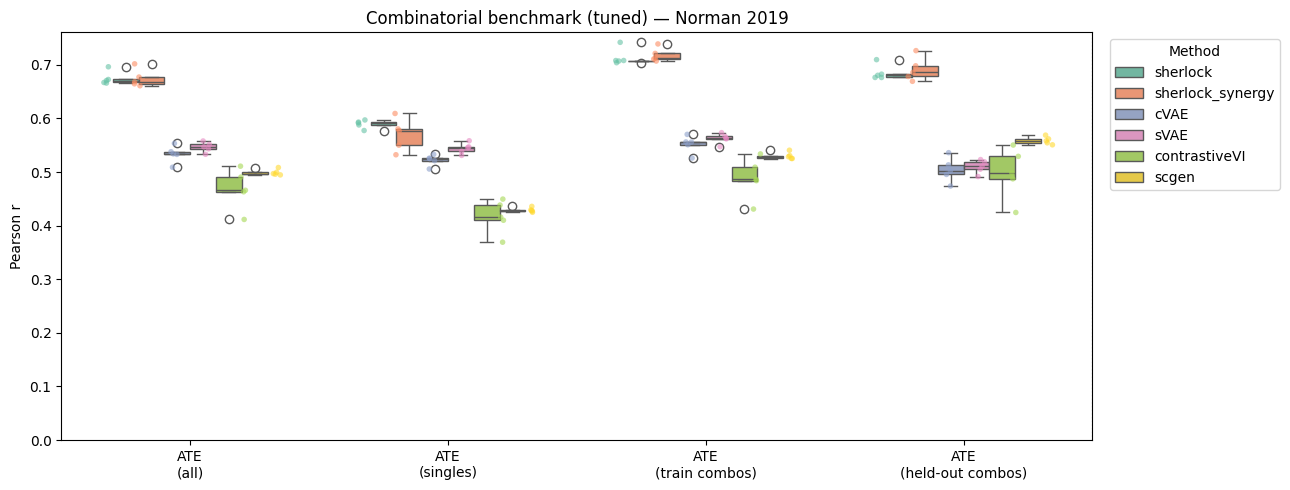

In [11]:
label_map = {
    'ate_all_r':         'ATE\n(all)',
    'ate_single_r':      'ATE\n(singles)',
    'ate_train_combo_r': 'ATE\n(train combos)',
    'ate_held_r':        'ATE\n(held-out combos)',
    'rho_z_pearson_r':   'ρ-z\nCorr r',
}

df_melted = results_df.melt(
    id_vars='method', value_vars=METRIC_COLS[:-1], var_name='metric', value_name='value'
)
df_melted['metric_label'] = pd.Categorical(
    df_melted['metric'].map(label_map),
    categories=[label_map[m] for m in METRIC_COLS[:-1]],
    ordered=True,
)
df_melted['method'] = pd.Categorical(
    df_melted['method'], categories=method_order, ordered=True
)
df_melted['value'] = df_melted['value'].clip(lower=0)

single_sample = df_melted.groupby(['metric', 'method'])['value'].size().max() == 1

fig, ax = plt.subplots(figsize=(13, 5))

if single_sample:
    sns.barplot(
        data=df_melted, x='metric_label', y='value', hue='method',
        palette='Set2', ax=ax, errorbar=None,
    )
else:
    sns.boxplot(
        data=df_melted, x='metric_label', y='value', hue='method',
        palette='Set2', width=0.6, ax=ax,
    )
    sns.stripplot(
        data=df_melted, x='metric_label', y='value', hue='method',
        palette='Set2', dodge=True, size=4, alpha=0.6, legend=False, ax=ax,
    )

ax.set_xlabel('')
ax.set_ylabel('Pearson r')
ax.set_title('Combinatorial benchmark (tuned) — Norman 2019')
ax.legend(title='Method', bbox_to_anchor=(1.01, 1), loc='upper left')
ax.set_ylim(bottom=0)
ax.axhline(0, color='gray', linewidth=0.5, linestyle='--')
# Separator: ATE metrics | rho_z
ax.axvline(3.5, color='lightgray', linewidth=1.0, linestyle=':')

plt.tight_layout()
plot_name = 'benchmark_barplot.pdf' if single_sample else 'benchmark_boxplot.pdf'
plt.savefig(f'{RESULTS_DIR}/figures/{plot_name}', bbox_inches='tight')
plt.show()